In [1]:
import cycler
import json
import itertools
import os
import pathlib
import subprocess
import sys

from IPython.display import Code
import IPython
import matplotlib
import matplotlib.pyplot
import matplotlib.ticker
import numpy
import pandas


IMPL_DIR = pathlib.Path.cwd() / "05_implementation"
os.environ["IMPL_DIR"] = str(IMPL_DIR)
if str(IMPL_DIR) not in sys.path:
    sys.path.append(str(IMPL_DIR))

RIOT_PATH = IMPL_DIR / "RIOT"
COSY_DIR = RIOT_PATH / "build" / "pkg" / "cosy"

from utils import list_code

# Evaluating the Name Compressors

If you only cloned the Git repository, you will only have the bare minimum files to generate Figure 15. You can find all other files in `05_implementation.tar.zst` on [Zenodo](https://doi.org/10.5281/zenodo.21790597) and unpack them with the following command:

In [ ]:
%%bash

RECORD_URL=$( \
    wget -O /dev/null "https://doi.org/10.5281/zenodo.21790597" 2>&1 | \
    grep -w 'Location' | tail -n 1 | grep -o 'https://[^ ]\+[0-9]' \
)

wget -O 05_implementation.tar.zst "${RECORD_URL}/files/05_implementation.tar.zst?download=1"
md5sum --status -c "${IMPL_DIR}"/05_implementation.tar.zst.md5sum && \
    tar -C "${IMPL_DIR}/.." -I 'zstd -T0' -xf 05_implementation.tar.zst -C "${IMPL_DIR}/.."

## Runtime Analysis `cbor4dns`

This covers our evaluation in Section V “Evaluating the Name Compressors” and  results in the plots shown in Figure 15 of our paper.

### Measuring Runtime

For this, you require the `dns_data_iot.csv.gz` in `04_cbor4dns_eval/output_datasets/` as generated in [“Extract DNS Data from PCAPs“ in the dataset collection notebook](./04_cbor4dns_eval/01_dataset_collection.ipynb#Extract-DNS-Data-from-PCAPs) of `04_cbor4dns_eval`.

We ran our evaluation using `dnspython` and different configurations (_i.e._, branches) of `cbor4dns` (see also [“Encode to application/dns+cbor”](./04_cbor4dns_eval/02_encoding.ipynb)) on an AMD EPYC 7702.

Make sure, all submodules are up to date with the following command.

In [3]:
%%bash

git -C "${IMPL_DIR}"/.. submodule update --init

Submodule path '04_cbor4dns_eval/cbor4dns': checked out 'd4c444175692a0b5625f2d3625adfb24cfe5ce4c'


We measured runtimes using the `05_implementation/dns_cbor_runtime.sh` script.

In [4]:
!"{IMPL_DIR}"/dns_cbor_runtime.sh -h

Usage: /app/05_implementation/dns_cbor_runtime.sh [-d|-p] [-t <tag number] -o <output_file>


Use the `-d` flag to measure the classic `application/dns-message` format with `dnspython`.
Use the `-p` flag to measure a packed version of `application/dns+cbor`.
Without any flag, the unpacked version of `application/dns+cbor` for the corresponding `cbor4dns` branch is measured.
`-t <tag number>` determines $t$ when using with Name Component Referencing and determines the tag size (the script errors if the right cbor4dns branch is not checked out).

Each encoding and decoding step is measured 100 times.

In [5]:
list_code(IMPL_DIR / "dns_cbor_runtime.sh")

#!/usr/bin/env bash
#
# Copyright (C) 2024-26 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR="$( cd -- "$( dirname -- "${BASH_SOURCE[0]}" )" &> /dev/null && pwd )"
INPUT_DATASETS=${INPUT_DATASETS:-${SCRIPT_DIR}/../04_cbor4dns_eval/output_datasets}
PROCS=$(grep -c '^processor' /proc/cpuinfo)
ITERATIONS=100
FLAGS=""

if [ $PROCS -gt 64 ]; then
    # leave some resources to collegues ;-)
    # PROCS=$(( (PROCS * 3) / 4))
    PROCS=32
fi

usage() {
    echo "Usage: $0 [-d|-p] [-t <tag number] -o <output_file>" >&2
}

while getopts 'dpho:t:' OPTION; do
  case "$OPTION" in
    d)  FLAGS="${FLAGS} -d"
      	;;
    p)  FLAGS="${FLAGS} -p"
        ;;
    t)  FLAGS="${FLAGS} -t ${OPTARG}"
        ;;
    h)  usage
        exit 1
        ;;
    o)  OUTPUT_FILE="${OPTARG}"
        ;;
    ?)  usage
        exit 1
        ;;
  esac
done

if [ -z "${OUTPUT_FILE}" ]; then
    usage
    exit 1
fi

zcat "${INPUT_DATASETS}"/dns_data_iot.csv.gz | \
    "${SCRIPT_DIR}/dns_cbor_runtime.py" ${FLAGS} -i ${ITERATIONS} --header | \
    pigz > "${OUTPUT_FILE}"

zcat "${INPUT_DATASETS}"/dns_data_iot.csv.gz | \
    parallel -j$PROCS --spreadstdin --line-buffer \
        "${SCRIPT_DIR}/dns_cbor_runtime.py" ${FLAGS} -i ${ITERATIONS} | \
    pigz >> "${OUTPUT_FILE}"

In [6]:
list_code(IMPL_DIR / "dns_cbor_runtime.py")

#!/usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2024-26 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import csv
import io
import os
import pathlib
import subprocess
import sys
import timeit

import cbor2
import dns.message
import dns.name
import dns.rdatatype

SCRIPT_PATH = pathlib.Path(os.path.dirname(os.path.realpath(__file__)))
CBOR4DNS_PATH = str((SCRIPT_PATH / ".." / "04_cbor4dns_eval" / "cbor4dns").resolve())
TAXONOMY_PATH = str((SCRIPT_PATH / "..").resolve())

if CBOR4DNS_PATH not in sys.path:
    sys.path.append(CBOR4DNS_PATH)
import cbor4dns.encode
import cbor4dns.decode

if TAXONOMY_PATH not in sys.path:
    sys.path.append(TAXONOMY_PATH)
from utils import taxonomy

INPUT_FIELDNAMES = [
    "dataset",
    "pcap",
    "frame.number",
    "frame.protocols",
    "_ws.col.Source",
    "_ws.col.Destination",
    "dns.flags.response",
    "dns.qry.type",
    "dns.resp.type",
    "dns.retransmit_response_in",
    "dns.response_to",
    "payload",
    "dns.qry.name",
    "dns.resp.name",
    "dns.afsdb.hostname",
    "dns.cname",
    "dns.dname",
    "dns.mr",
    "dns.ns",
    "dns.nsec.next_domain_name",
    "dns.ptr.domain_name",
    "dns.rrsig.signers_name",
    "dns.rt.intermediate_host",
    "dns.soa.mname",
    "dns.soa.rname",
    "dns.srv.name",
    "dns.svcb.targetname",
    "dns.winsr.name_result_domain",
    "dns.a",
    "dns.aaaa",
    "dns.apl.afdpart.ipv4",
    "dns.apl.afdpart.ipv6",
    "dns.ilnp.l32",
    "dns.ipseckey.gateway_ipv4",
    "dns.ipseckey.gateway_ipv6",
    "dns.svcb.svcparam.ipv4hint.ip",
    "dns.svcb.svcparam.ipv6hint.ip",
    "dns.wins.wins_server",
    "dns.wks.address",
    "dns.xpf.destination_ipv4",
    "dns.xpf.destination_ipv6",
    "dns.xpf.source_ipv4",
    "dns.xpf.source_ipv6",
    "dns.query_payload",
    "qr-diff",
    "stored",
]
MSG_TYPES = {
    "q": cbor4dns.decode.MsgType.QUERY,
    "r": cbor4dns.decode.MsgType.RESPONSE,
}


def dns_encode(dns_msg):
    return dns_msg.to_wire(want_shuffle=False)


def dns_decode(dns_bin):
    return dns.message.from_wire(dns_bin)


def cbor_encode(encoder, dns_msg, orig_query=None):
    encoder.fp.seek(0)
    encoder.encode(dns_msg, orig_query)


def cbor_decode(decoder, msg_type, packed, orig_query=None):
    decoder.fp.seek(0)
    return decoder.decode(msg_type, orig_query=orig_query, packed=packed)


def cbor_encode_to_bytes(dns_msg, packed, orig_query=None):
    with io.BytesIO() as cbor_file:
        encoder = cbor4dns.encode.Encoder(
            cbor_file,
            packed=packed,
            always_omit_question=False,
        )
        cbor_encode(encoder, dns_msg, orig_query)
        return cbor_file.getvalue()


def main():
    TAG_TYPE = ""
    PACKED_VAL = 1
    argparser = argparse.ArgumentParser()
    argparser.add_argument("-i", "--iterations", type=int, required=True)
    argparser.add_argument("--header", action="store_true")
    measure_group = argparser.add_mutually_exclusive_group(required=False)
    measure_group.add_argument("-d", "--measure-dns", action="store_true")
    measure_group.add_argument("-p", "--measure-packed", action="store_true")
    if hasattr(cbor4dns.encode, "RefIdx"):
        argparser.add_argument(
            "-t",
            "--tag",
            type=int,
            required=True,
            help="Tag number for name compression referencing",
        )
    args = argparser.parse_args()

    measure_dns = args.measure_dns
    measure_packed = args.measure_packed
    cols = {}
    git_branch = subprocess.check_output(
        ["git", "-C", str(CBOR4DNS_PATH), "rev-parse", "--abbrev-ref", "HEAD"],
        text=True,
    ).strip()
    if git_branch == "packed-lite":
        if not args.measure_packed:
            assert git_branch != "packed-lite", (
                "On packed-lite branch, but not measuring packed. Set -p flag."
            )
        PACKED_VAL = "lite"
        measure_dns = False
    if hasattr(cbor4dns.encode, "RefIdx"):
        if args.

To start a detached TMUX session running this script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${IMPL_DIR}'/../.env/bin/activate;` before the first `${IMPL_DIR}/dns_cbor_runtime.sh`):

In [7]:
%%bash

tmux new-session -s "dns_runtime" -d \
    "'${IMPL_DIR}'/dns_cbor_runtime.sh -d \
        -o '${IMPL_DIR}'/output_datasets/dns_cbor_dns_runtime_iot.csv.gz; \
     git -C '${IMPL_DIR}'/../04_cbor4dns_eval/cbor4dns checkout draft-lenders-dns-cbor-06; \
     '${IMPL_DIR}'/dns_cbor_runtime.sh \
        -o '${IMPL_DIR}'/output_datasets/dns_cbor_classic_unpacked_runtime_iot.csv.gz; \
     '${IMPL_DIR}'/dns_cbor_runtime.sh -p \
        -o '${IMPL_DIR}'/output_datasets/dns_cbor_classic_packed_runtime_iot.csv.gz; \
     git -C '${IMPL_DIR}'/../04_cbor4dns_eval/cbor4dns checkout name-compr-str-ref; \
     '${IMPL_DIR}'/dns_cbor_runtime.sh -t 7 \
        -o '${IMPL_DIR}'/output_datasets/dns_cbor_name_comp7_runtime_iot.csv.gz; \
     '${IMPL_DIR}'/dns_cbor_runtime.sh -t 48 \
        -o '${IMPL_DIR}'/output_datasets/dns_cbor_name_comp48_runtime_iot.csv.gz; \
     git -C '${IMPL_DIR}'/../04_cbor4dns_eval/cbor4dns checkout packed-lite; \
     '${IMPL_DIR}'/dns_cbor_runtime.sh -p \
        -o '${IMPL_DIR}'/output_datasets/dns_cbor_packed_lite_runtime_iot.csv.gz"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "dns_runtime"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "dns_runtime" C-c
```

### Generate Histograms

In [8]:
list_code(IMPL_DIR / "hist_metric.awk")

BEGIN {
    OFS=FS=","
    factor=10000
    start_col=9
}
NR == 1 {
    gsub(/[[:cntrl:][:space:]]+$/,"")
    for (c = start_col; c <= NF; c++) {
        names[c] = $c
    }
}
NR > 1 {
    gsub(/[[:cntrl:][:space:]]+$/,"")
    for (c = start_col; c <= NF; c++) {
        if (($c < 0) && (factor != 1)) {
            bin=int($c*factor)-1
        } else {
            bin=int($c*factor)
        }
        A[$1][$4][$5][$6][$7][$8][bin][c]++
    }
}
END {
    printf "dataset" OFS;
    printf "protocol" OFS;
    printf "msg" OFS;
    printf "qtype" OFS;
    printf "w_query" OFS; 
    printf "x" OFS;
    for (c = start_col; c < NF; c++) {
        printf names[c] OFS;
    }
    printf names[NF] "\n";
    for (dataset in A) {
        for (protocol in A[dataset]) {
            for (msg in A[dataset][protocol]) {
                for (qtype in A[dataset][protocol][msg]) {
                    for (w_query in A[dataset][protocol][msg][qtype]) {
                        for (i in A[dataset][protocol][msg][qtype][w_query]) {
                            for (bin in A[dataset][protocol][msg][qtype][w_query][i]) {
                                printf dataset OFS;
                                printf protocol OFS;
                                printf msg OFS;
                                printf qtype OFS;
                                printf w_query OFS;
                                printf (bin/factor)/i OFS;
                                for (c = start_col; c < NF; c++) {
                                    printf A[dataset][protocol][msg][qtype][w_query][i][bin][c] OFS; 
                                }
                                printf A[dataset][protocol][msg][qtype][w_query][i][bin][NF] "\n";
                            }
                        }
                    }
                }
            }
        }
    }
}

In [9]:
%%bash

for file in "${IMPL_DIR}/output_datasets/dns_cbor_"*"_runtime_iot.csv.gz"; do
    hist_file=$(echo "${file}" | sed -e 's/_runtime_/_hist_runtime_/' -e 's/\.gz$//')
    zcat "${file}" | awk -f "${IMPL_DIR}/hist_metric.awk" > "${hist_file}"
done

### Plot CDFs

,mean [μs],std [μs],min [μs],median [μs],max [μs]
dnspython,71.0,40.0,18.0,38.0,572.0
cbor4dns,63.0,54.0,20.0,27.0,266.0
cbor4dns + Component Referencing (1+0),92.0,89.0,21.0,47.0,305.0
cbor4dns + Component Referencing (1+1),70.0,83.0,21.0,48.0,300.0
cbor4dns + Packed Lite,255.0,242.0,48.0,103.0,600.0
cbor4dns (packed),65.0,271.0,54.0,170.0,656.0


#### [Encode](05_implementation/plots/dns-times-encode.pdf)

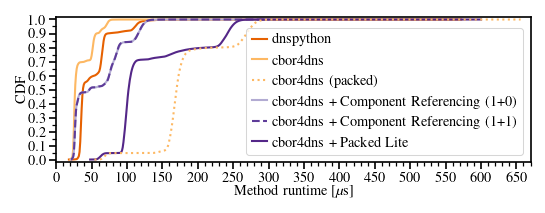

,mean [μs],std [μs],min [μs],median [μs],max [μs]
dnspython,241.0,123.0,33.0,43.0,584.0
cbor4dns,175.0,71.0,11.0,18.0,366.0
cbor4dns + Component Referencing (1+0),95.0,31.0,17.0,69.0,495.0
cbor4dns + Component Referencing (1+1),96.0,80.0,16.0,69.0,463.0
cbor4dns + Packed Lite,129.0,197.0,18.0,84.0,526.0
cbor4dns (packed),205.0,196.0,18.0,84.0,589.0


#### [Decode](05_implementation/plots/dns-times-decode.pdf)

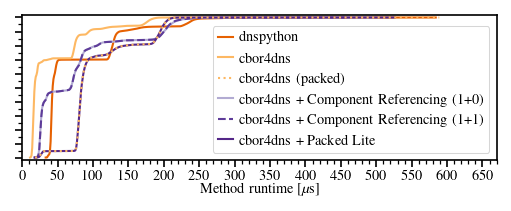

In [10]:
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ["#e66101", "#fdb863", "#b2abd2", "#5e3c99", "#542788"]
)

COLUMNS = {
    "application/dns-message decode": "dnspython",
    "application/dns-message encode": "dnspython",
    "application/cbor+dns decode": "cbor4dns",
    "application/cbor+dns encode": "cbor4dns",
    "application/cbor+dns;packed=1 decode": "cbor4dns (packed)",
    "application/cbor+dns;packed=1 encode": "cbor4dns (packed)",
    "application/cbor+dns t7 decode": "cbor4dns + Component Referencing (1+0)",
    "application/cbor+dns t7 encode": "cbor4dns + Component Referencing (1+0)",
    "application/cbor+dns t48 decode": "cbor4dns + Component Referencing (1+1)",
    "application/cbor+dns t48 encode": "cbor4dns + Component Referencing (1+1)",
    "application/cbor+dns;packed=lite decode": "cbor4dns + Packed Lite",
    "application/cbor+dns;packed=lite encode": "cbor4dns + Packed Lite",
}
STYLES={
    "dnspython": "C0",
    "cbor4dns": "C1",
    "cbor4dns (packed)": "C1:",
    "cbor4dns + Component Referencing (1+0)": "C2",
    "cbor4dns + Component Referencing (1+1)": "C3--",
    "cbor4dns + Packed Lite": "C4",
}


def mean_bin(df, column):
    # https://stackoverflow.com/a/37265494
    sdf = df.reset_index(drop=False, names=["bin"]).sort_values(column).reset_index(drop=True)
    mean_idx = sdf[column].searchsorted(sdf[column].mean())
    if mean_idx > 0:
        res = sdf.loc[mean_idx - 1]
        return res["bin"]
    return numpy.nan


def std_bin(df, column):
    sdf = df.reset_index(drop=False, names=["bin"]).sort_values(column).reset_index(drop=True)
    std_idx = sdf[column].searchsorted(sdf[column].std())
    if std_idx > 0:
        res = sdf.loc[std_idx - 1]
        return res["bin"]
    return numpy.nan


def median_bin(df, column):
    # https://math.stackexchange.com/a/2591986
    total = 0
    median_index = (df[column].sum() + 1) / 2
    for value in df.index.sort_values():
        total += df.loc[value].fillna(0)[column]
        if total > median_index:
            return value
    return numpy.nan


def stats_func(x):
    return x * 1000000


for method in ["encode", "decode"]:
    matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.0,
        matplotlib.rcParams["figure.figsize"][1] * 4 / 8,
    )
    fig = matplotlib.pyplot.figure(
        figsize=matplotlib.rcParams["figure.figsize"],
        dpi=150,
    )

    stats_unit = r"μs"
    stats = {
        f"mean [{stats_unit}]": {},
        f"std [{stats_unit}]": {},
        f"min [{stats_unit}]": {},
        f"median [{stats_unit}]": {},
        f"max [{stats_unit}]": {},
    }
    ax = matplotlib.pyplot.gca()
    for file in [
        IMPL_DIR / "output_datasets" / "dns_cbor_dns_hist_runtime_iot.csv",
        IMPL_DIR / "output_datasets" / "dns_cbor_classic_unpacked_hist_runtime_iot.csv",
        IMPL_DIR / "output_datasets" / "dns_cbor_name_comp7_hist_runtime_iot.csv",
        IMPL_DIR / "output_datasets" / "dns_cbor_name_comp48_hist_runtime_iot.csv",
        IMPL_DIR / "output_datasets" / "dns_cbor_packed_lite_hist_runtime_iot.csv",
        IMPL_DIR / "output_datasets" / "dns_cbor_classic_packed_hist_runtime_iot.csv",
    ]:
        df = pandas.read_csv(file, index_col=["dataset", "protocol", "msg", "qtype", "w_query", "x"])
          
        for column in df.columns:
            if method not in column:
                continue
            if "classic_hist" in str(file) and "packed=1" in column:
                continue
            hist = df[[column]].dropna()
            hist = hist.reset_index()[["x", column]].groupby("x").sum()
            stats[f"mean [{stats_unit}]"][column] = stats_func(mean_bin(hist, column))
            stats[f"std [{stats_unit}]"][column] = stats_func(std_bin(hist, column))
            stats[f"min [{stats_unit}]"][column] = stats_func(hist[column][hist[column] > 0].index.min())
            stats[f"median [{stats_unit}]"][column] = stats_func(median_bin(hist, column))
            stats[f"max [{stats_unit}]"][column] = stats_func(hist[column][hist[column] > 0].index.max())
            # with pandas.option_context("display.max_rows", None):
            #     IPython.display.display(hist)
            hist[column] = hist[column] / (hist[column].sum())
            for x1, x2 in itertools.pairwise(hist[column].sort_index().index):
                hist.loc[x2, column] = hist.loc[x1, column] + hist.loc[x2, column]
            hist.rename(columns=COLUMNS).plot(ax=ax, style=STYLES)

    stats = pandas.DataFrame(stats).rename(index=COLUMNS)
    IPython.display.display(stats)
    # create CDF
    
    ax.set_xlim((0, 0.00067))
    ax.set_xticks(numpy.arange(0, 0.00067, 0.00005))
    ax.xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 1000000:0.0f}$")
    )
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.00001))
    ax.set_xlabel(r"Method runtime [$\mu$s]")
    ax.set_ylim((-0.02, 1.02))
    if method == "encode":
        ax.set_yticks(numpy.arange(0, 1.05, 0.1))
        ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
        ax.set_ylabel("CDF")
    else:
        ax.set_yticks(numpy.arange(0, 1.1, 0.1), [])
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.05))
    handles, labels = ax.get_legend_handles_labels()
    handles = handles[:2] + handles[-1:] + handles[2:-1]
    labels = labels[:2] + labels[-1:] + labels[2:-1]
    ax.legend(handles=handles, labels=labels, loc="lower right")
    filename = f"dns-times-{method}.pdf"
    IPython.display.display(
        IPython.display.Markdown(
            f"#### [{method.title()}]({IMPL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
        )
    )
    matplotlib.pyplot.savefig(
        IMPL_DIR / "plots" / filename,
        bbox_inches="tight",
        pad_inches=0.01,
    )
    matplotlib.pyplot.show()

## Build Size Analysis for Constrained Implementation

This provides the build size statistics we describe in Section V “Evaluating the Name Compressors”.

### Generate `symbols.json` for Static Code Analysis

Make sure, all submodules are up to date with the following command.

In [11]:
%%bash

git -C "${IMPL_DIR}"/.. submodule update --init "${IMPL_DIR}/RIOT"

In [12]:
RIOT_PATH = IMPL_DIR / "RIOT"
COSY_DIR = RIOT_PATH / "build" / "pkg" / "cosy"

In [13]:
COSY_PATH = COSY_DIR / "cosy.py"
DNS_CBOR_TEST = RIOT_PATH / "tests" / "net" / "dns_cbor"
DNS_CBOR_TEST_NAME = "tests_dns_cbor"
BOARD = "nrf52840dongle"
DNS_CBOR_TEST_BUILD_PATH = DNS_CBOR_TEST / "bin" / BOARD

os.environ["BOARD"] = BOARD
os.environ["QUIETER"] = "1"
os.environ["DEVELHELP"] = "0"
os.environ["WERROR"] = "0"
os.environ["CFLAGS_OPT"] = "-Os"
os.environ["CFLAGS_DBG"] = "-g3"

!make -C "{DNS_CBOR_TEST}" "{COSY_PATH}"
!make -C "{DNS_CBOR_TEST}" clean
!make -C "{DNS_CBOR_TEST}" all -j

subprocess.check_call(
    [
        str(COSY_PATH), "-d", "--riot-base", str(RIOT_PATH),
        str(DNS_CBOR_TEST), BOARD,
        DNS_CBOR_TEST_BUILD_PATH / f"{DNS_CBOR_TEST_NAME}.elf",
        DNS_CBOR_TEST_BUILD_PATH / f"{DNS_CBOR_TEST_NAME}.map",
    ],
    stderr=subprocess.DEVNULL,
)
!cp "{COSY_DIR}/root/symbols.json" "{IMPL_DIR}/output_datasets/"
print("Finished")

make: Entering directory '/app/05_implementation/RIOT/tests/net/dns_cbor'
[INFO] cosy.py not found - fetching it from GitHub now
:
[INFO] cosy.py successfully fetched!
make: Leaving directory '/app/05_implementation/RIOT/tests/net/dns_cbor'
make: Entering directory '/app/05_implementation/RIOT/tests/net/dns_cbor'
rm -rf /app/05_implementation/RIOT/tests/net/dns_cbor/bin/nrf52840dongle/pkg-build/cmsis
rm -rf /app/05_implementation/RIOT/tests/net/dns_cbor/bin/nrf52840dongle/pkg-build/nanocbor
make: Leaving directory '/app/05_implementation/RIOT/tests/net/dns_cbor'
make: Entering directory '/app/05_implementation/RIOT/tests/net/dns_cbor'
Building application "tests_dns_cbor" for "nrf52840dongle" with CPU "nrf52".

   text	   data	    bss	    dec	    hex	filename
  25360	    128	   5856	  31344	   7a70	/app/05_implementation/RIOT/tests/net/dns_cbor/bin/nrf52840dongle/tests_dns_cbor.elf
make: Leaving directory '/app/05_implementation/RIOT/tests/net/dns_cbor'

Result validation: both size ou

### Plot Build Sizes and Sum Up Name Compression Code Size

#### [Overall Code Size](05_implementation/plots/dns_cbor_riot_build_size.pdf)

size
module   component type      
dns      encoder   ROM    196
         decoder   ROM   1422
nanocbor encoder   ROM    376
         decoder   ROM    740
app      state     RAM    168

<Figure size 642.679x126.094 with 0 Axes>

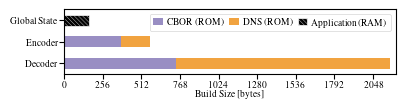

#### Name Component Code Size

,sym,path,module,type,size
75,_extend_name,sys/net/application_layer/dns,dns,ROM,62
76,_parse_name,sys/net/application_layer/dns,dns,ROM,252
0,Sum,sys/net/application_layer/dns,dns,ROM,314


In [14]:
COLORS = [
    "#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99",
    "#e31a1c", "#fdbf6f", "#ff7f00", "#cab2d6", "#6a3d9a",
    "#ffff99", "#b15928"
]
MODULE_PATHS = {
    "sys/net/application_layer/dns": "dns",
    "pkg/nanocbor/src": "nanocbor",
    "tests/net/dns_cbor": "app",
}
FILTER = {
    "encoder": {
        "dns": lambda df: (df["obj"] == "cbor.o") & df["sym"].isin(("dns_cbor_compose_query", )),
        "nanocbor": lambda df: df["obj"] == "encoder.o",
        "app": lambda df: df.isna(),
    },
    "decoder": {
        "dns": lambda df: (df["obj"] == "cbor.o") & df["sym"].isin(("_extend_name", "_parse_name", "dns_cbor_parse_response", )),
        "nanocbor": lambda df: df["obj"] == "decoder.o",
        "app": lambda df: df.isna(),
    },
    "state": {
        "dns": lambda df: df.isna(),
        "nanocbor": lambda df: df.isna(),
        "app": lambda df: (df["obj"] == "main.o") & df["sym"].isin(("_buf", "_buf_len", "_status")),
    }
}


with open(IMPL_DIR / "output_datasets" / "symbols.json") as f:
    symbols = json.load(f)
df = pandas.DataFrame(symbols["symbols"])
df["path"] = df["path"].apply(lambda path: "/".join(path))
df["type"] = df["type"].apply(lambda x: "ROM" if x == "t" else "RAM")
df = df[df["path"].isin(tuple(MODULE_PATHS))]
df["module"] = df["path"].apply(lambda path: MODULE_PATHS[path])
df.insert(len(df.columns), "component", [""] * df.shape[0])

res = None
for module in MODULE_PATHS.values():
    for key in FILTER:
        df.loc[:, "component"] = key
        tmp = df[FILTER[key][module]].groupby(["module", "component", "type"])["size"].sum().to_frame()
        if tmp.empty:
            continue
        if res is None:
            res = tmp
        else:
            res = pandas.concat([res, tmp])
plot = res.unstack(level=[0, 2]).rename(columns={"app": "Application", "dns": "DNS", "nanocbor": "CBOR"})
plot.columns = [f"{c[1]} ({c[2]})" for c in plot.columns]
plot = plot[["CBOR (ROM)", "DNS (ROM)", "Application (RAM)"]]

matplotlib.style.use(pathlib.Path.cwd() / f"mlenders_column_ieeetran.mplstyle")
color_cycler = ["#998ec3", "#f1a340", "#030303"]
matplotlib.pyplot.rc("axes", prop_cycle=cycler.cycler(color=color_cycler))
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.05,
    matplotlib.rcParams["figure.figsize"][1] / 3
)
fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = plot.plot.barh(stacked=True, legend=False, hatch=["", "", r"\\\\\\\\"], edgecolor=["none", "none", "white"])
handles, labels = ax.get_legend_handles_labels()
handles[2].patches[0].set_hatch(r"\\\\\\\\")
handles[2].patches[0].set_edgecolor("white")
matplotlib.pyplot.legend(handles=handles, labels=labels, ncol=3, loc="upper right")
ax.set_xlabel("Build Size [bytes]")
ax.set_xlim((0, 2200))
ax.set_xticks(range(0, 2200, 256))
ax.set_ylabel("")
ax.set_yticks(range(0, 3, 1), ["Decoder", "Encoder", "Global State"])
filename = "dns_cbor_riot_build_size.pdf"
matplotlib.pyplot.savefig(
    IMPL_DIR / "plots" / filename,
    bbox_inches="tight",
    pad_inches=0.01,
)
IPython.display.display(
    IPython.display.Markdown(
        f"#### [Overall Code Size]"
        f"({IMPL_DIR.relative_to(pathlib.Path.cwd()) / 'plots' / filename})"
    )
)
IPython.display.display(res)
matplotlib.pyplot.show()
IPython.display.display(
    IPython.display.Markdown(
        "#### Name Component Code Size"
    )
)
name_comp_code = df[
    (df["module"] == "dns") & df["sym"].isin(("_extend_name", "_parse_name"))
].sort_values("size")[["sym", "path", "module", "type", "size"]]
name_comp_sum = name_comp_code.groupby(["path", "module", "type"]).sum().reset_index()
name_comp_sum["sym"] = "Sum"
name_comp_code = pandas.concat(
    [
        name_comp_code,
        name_comp_sum,
    ]
)
IPython.display.display(name_comp_code)